In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
n_candidates = 1000

candidate_data = pd.DataFrame({
    "candidate_id": range(1, n_candidates + 1),

    "education_level": np.random.choice(
        ["Diploma", "Bachelor's", "Master's"],
        n_candidates,
        p=[0.10, 0.60, 0.30]
    ),

    "experience_years": np.round(
        np.random.exponential(scale=2.5, size=n_candidates),
        1
    ).clip(0, 12),

    "python": np.random.binomial(1, 0.55, n_candidates),
    "sql": np.random.binomial(1, 0.50, n_candidates),
    "machine_learning": np.random.binomial(1, 0.35, n_candidates),
    "deep_learning": np.random.binomial(1, 0.25, n_candidates),
    "power_bi": np.random.binomial(1, 0.30, n_candidates),
    "excel": np.random.binomial(1, 0.60, n_candidates),
    "cloud": np.random.binomial(1, 0.20, n_candidates),

    "certification_count": np.random.poisson(2, n_candidates).clip(0, 8),

    "project_count": np.random.poisson(3, n_candidates).clip(0, 10),

    "internship_experience": np.random.binomial(
        1, 0.45, n_candidates
    )
})

candidate_data.head()

,candidate_id,education_level,experience_years,python,sql,machine_learning,deep_learning,power_bi,excel,cloud,certification_count,project_count,internship_experience
0,1,Bachelor's,0.5,1,1,0,0,0,1,0,4,4,1
1,2,Master's,2.0,1,1,1,0,0,1,0,1,5,0
2,3,Master's,5.2,0,0,1,1,1,0,0,3,4,1
3,4,Bachelor's,3.3,1,1,0,0,0,0,1,1,3,1
4,5,Bachelor's,4.1,1,1,0,1,0,1,0,0,4,1


In [3]:
print("Shape:", candidate_data.shape)
print("\nColumns:")
print(candidate_data.columns.tolist())

print("\nMissing values:")
print(candidate_data.isnull().sum())

Shape: (1000, 13)

Columns:
['candidate_id', 'education_level', 'experience_years', 'python', 'sql', 'machine_learning', 'deep_learning', 'power_bi', 'excel', 'cloud', 'certification_count', 'project_count', 'internship_experience']

Missing values:
candidate_id             0
education_level          0
experience_years         0
python                   0
sql                      0
machine_learning         0
deep_learning            0
power_bi                 0
excel                    0
cloud                    0
certification_count      0
project_count            0
internship_experience    0
dtype: int64


In [4]:
n_jobs = 100

job_data = pd.DataFrame({
    "job_id": range(1, n_jobs + 1),

    "job_domain": np.random.choice(
        [
            "Data Science",
            "Data Analyst",
            "Machine Learning",
            "AI Engineer",
            "Business Intelligence"
        ],
        n_jobs
    ),

    "required_experience": np.random.choice(
        [0, 1, 2, 3, 4, 5],
        n_jobs,
        p=[0.10, 0.20, 0.25, 0.20, 0.15, 0.10]
    ),

    "python_required": np.random.binomial(1, 0.60, n_jobs),
    "sql_required": np.random.binomial(1, 0.55, n_jobs),
    "ml_required": np.random.binomial(1, 0.40, n_jobs),
    "dl_required": np.random.binomial(1, 0.25, n_jobs),
    "power_bi_required": np.random.binomial(1, 0.30, n_jobs),
    "excel_required": np.random.binomial(1, 0.50, n_jobs),
    "cloud_required": np.random.binomial(1, 0.20, n_jobs),

    "minimum_education": np.random.choice(
        ["Diploma", "Bachelor's", "Master's"],
        n_jobs,
        p=[0.10, 0.65, 0.25]
    )
})

job_data.head()

,job_id,job_domain,required_experience,python_required,sql_required,ml_required,dl_required,power_bi_required,excel_required,cloud_required,minimum_education
0,1,Data Science,4,1,0,0,1,0,1,0,Bachelor's
1,2,Machine Learning,4,1,1,1,0,0,1,0,Diploma
2,3,AI Engineer,3,0,1,1,0,0,0,0,Diploma
3,4,Data Analyst,2,0,1,0,0,0,1,1,Bachelor's
4,5,Business Intelligence,4,0,1,0,0,0,1,0,Bachelor's


In [5]:
print("Shape:", job_data.shape)

print("\nMissing values:")
print(job_data.isnull().sum())

Shape: (100, 11)

Missing values:
job_id                 0
job_domain             0
required_experience    0
python_required        0
sql_required           0
ml_required            0
dl_required            0
power_bi_required      0
excel_required         0
cloud_required         0
minimum_education      0
dtype: int64


In [6]:
# Create candidate-job pairs

n_applications = 8000

applications = pd.DataFrame({
    "candidate_id": np.random.choice(
        candidate_data["candidate_id"],
        n_applications
    ),
    "job_id": np.random.choice(
        job_data["job_id"],
        n_applications
    )
})

# Attach candidate information
applications = applications.merge(
    candidate_data,
    on="candidate_id",
    how="left"
)

# Attach job information
applications = applications.merge(
    job_data,
    on="job_id",
    how="left"
)

print("Dataset shape:", applications.shape)

applications.head()

Dataset shape: (8000, 24)


,candidate_id,job_id,education_level,experience_years,python,sql,machine_learning,deep_learning,power_bi,excel,...,job_domain,required_experience,python_required,sql_required,ml_required,dl_required,power_bi_required,excel_required,cloud_required,minimum_education
0,81,21,Master's,3.9,1,1,1,0,0,1,...,Data Science,1,1,1,0,0,0,1,1,Bachelor's
1,615,78,Master's,1.0,1,0,0,0,0,1,...,Business Intelligence,5,1,0,0,0,1,1,0,Master's
2,483,79,Bachelor's,2.0,0,0,0,0,0,1,...,Data Science,3,1,1,0,0,0,1,0,Bachelor's
3,965,51,Bachelor's,2.1,0,0,0,0,0,1,...,Machine Learning,5,0,1,1,0,1,0,0,Master's
4,592,10,Bachelor's,11.8,0,0,0,0,0,0,...,AI Engineer,5,0,1,0,1,1,0,0,Master's


In [7]:
# Define candidate skills and corresponding job requirements

skill_pairs = {
    "python": "python_required",
    "sql": "sql_required",
    "machine_learning": "ml_required",
    "deep_learning": "dl_required",
    "power_bi": "power_bi_required",
    "excel": "excel_required",
    "cloud": "cloud_required"
}

# Calculate how many required skills the candidate possesses
matched_skills = np.zeros(len(applications))
required_skills = np.zeros(len(applications))

for candidate_skill, job_requirement in skill_pairs.items():
    matched_skills += (
        (applications[candidate_skill] == 1) &
        (applications[job_requirement] == 1)
    ).astype(int)

    required_skills += applications[job_requirement]

# Avoid division by zero
applications["skill_match_percentage"] = np.where(
    required_skills > 0,
    matched_skills / required_skills,
    0
)

# Convert to percentage
applications["skill_match_percentage"] = (
    applications["skill_match_percentage"] * 100
).round(2)

applications[
    [
        "candidate_id",
        "job_id",
        "skill_match_percentage"
    ]
].head(10)

,candidate_id,job_id,skill_match_percentage
0,81,21,75.00
1,615,78,66.67
2,483,79,33.33
3,965,51,0.00
4,592,10,0.00
5,407,55,0.00
6,103,36,25.00
7,240,51,66.67
8,265,74,50.00
9,33,17,66.67


In [8]:
print(
    applications["skill_match_percentage"].describe()
)

count    8000.000000
mean       44.840329
std        32.343064
min         0.000000
25%        25.000000
50%        50.000000
75%        66.670000
max       100.000000
Name: skill_match_percentage, dtype: float64


In [9]:
# Calculate experience match

applications["experience_ratio"] = np.where(
    applications["required_experience"] > 0,
    applications["experience_years"] /
    applications["required_experience"],
    1
)

# Cap the ratio at 1
applications["experience_match"] = (
    applications["experience_ratio"]
    .clip(upper=1)
    .round(2)
)

# View results
applications[
    [
        "experience_years",
        "required_experience",
        "experience_match"
    ]
].head(10)

,experience_years,required_experience,experience_match
0,3.9,1,1.00
1,1.0,5,0.20
2,2.0,3,0.67
3,2.1,5,0.42
4,11.8,5,1.00
5,4.6,2,1.00
6,5.4,0,1.00
7,0.5,5,0.10
8,0.0,1,0.00
9,0.7,4,0.18


In [10]:
# Education level mapping

education_mapping = {
    "Diploma": 1,
    "Bachelor's": 2,
    "Master's": 3
}

applications["candidate_education_score"] = (
    applications["education_level"].map(education_mapping)
)

applications["required_education_score"] = (
    applications["minimum_education"].map(education_mapping)
)

# Candidate meets or exceeds the minimum requirement
applications["education_match"] = (
    applications["candidate_education_score"] >=
    applications["required_education_score"]
).astype(int)

applications[
    [
        "education_level",
        "minimum_education",
        "education_match"
    ]
].head(10)

,education_level,minimum_education,education_match
0,Master's,Bachelor's,1
1,Master's,Master's,1
2,Bachelor's,Bachelor's,1
3,Bachelor's,Master's,0
4,Bachelor's,Master's,0
5,Bachelor's,Bachelor's,1
6,Bachelor's,Master's,0
7,Bachelor's,Master's,0
8,Master's,Bachelor's,1
9,Diploma,Bachelor's,0


In [11]:
# Practical experience feature

project_score = (
    applications["project_count"] / 5
).clip(upper=1)

internship_score = applications["internship_experience"]

applications["project_relevance"] = (
    0.7 * project_score +
    0.3 * internship_score
).round(2)

applications[
    [
        "project_count",
        "internship_experience",
        "project_relevance"
    ]
].head(10)

,project_count,internship_experience,project_relevance
0,2,0,0.28
1,2,0,0.28
2,4,0,0.56
3,0,1,0.30
4,1,0,0.14
5,1,0,0.14
6,4,1,0.86
7,2,1,0.58
8,7,0,0.70
9,2,0,0.28


In [12]:
# Create a latent compatibility score
# This is used only to generate the synthetic target.

np.random.seed(42)

# Normalize skill match from 0-100 to 0-1
skill_score = applications["skill_match_percentage"] / 100

# Combine multiple factors
latent_score = (
    0.40 * skill_score +
    0.25 * applications["experience_match"] +
    0.20 * applications["education_match"] +
    0.15 * applications["project_relevance"]
)

# Add controlled noise so the relationship isn't perfectly deterministic
noise = np.random.normal(
    loc=0,
    scale=0.12,
    size=len(applications)
)

latent_score = latent_score + noise

# Convert the latent score into a binary target
applications["compatibility"] = (
    latent_score >= 0.55
).astype(int)

# Inspect the target distribution
print(applications["compatibility"].value_counts())

print("\nTarget proportions:")
print(applications["compatibility"].value_counts(normalize=True))

compatibility
1    4601
0    3399
Name: count, dtype: int64

Target proportions:
compatibility
1    0.575125
0    0.424875
Name: proportion, dtype: float64


In [13]:
print("Dataset shape:", applications.shape)

print("\nData types:")
print(applications.dtypes)

print("\nMissing values:")
print(applications.isnull().sum().sum())

print("\nDuplicate rows:")
print(applications.duplicated().sum())

Dataset shape: (8000, 32)

Data types:
candidate_id                   int64
job_id                         int64
education_level               object
experience_years             float64
python                         int64
sql                            int64
machine_learning               int64
deep_learning                  int64
power_bi                       int64
excel                          int64
cloud                          int64
certification_count            int64
project_count                  int64
internship_experience          int64
job_domain                    object
required_experience            int64
python_required                int64
sql_required                   int64
ml_required                    int64
dl_required                    int64
power_bi_required              int64
excel_required                 int64
cloud_required                 int64
minimum_education             object
skill_match_percentage       float64
experience_ratio             float64

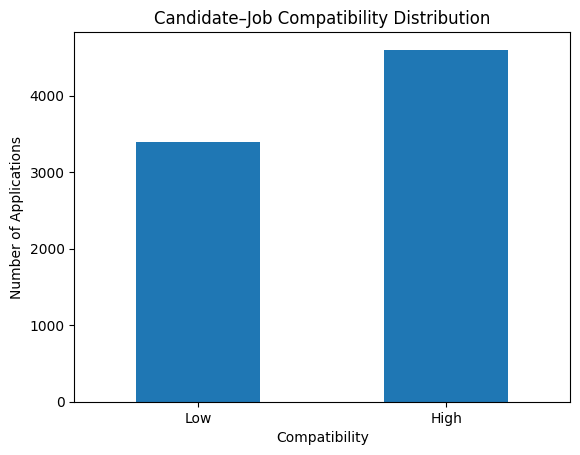

In [14]:
import matplotlib.pyplot as plt

applications["compatibility"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Candidate–Job Compatibility Distribution")
plt.xlabel("Compatibility")
plt.ylabel("Number of Applications")
plt.xticks([0, 1], ["Low", "High"], rotation=0)
plt.show()

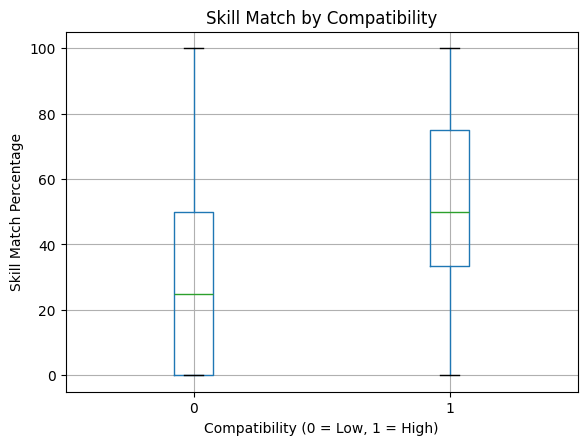

In [15]:
applications.boxplot(
    column="skill_match_percentage",
    by="compatibility"
)

plt.title("Skill Match by Compatibility")
plt.suptitle("")
plt.xlabel("Compatibility (0 = Low, 1 = High)")
plt.ylabel("Skill Match Percentage")
plt.show()

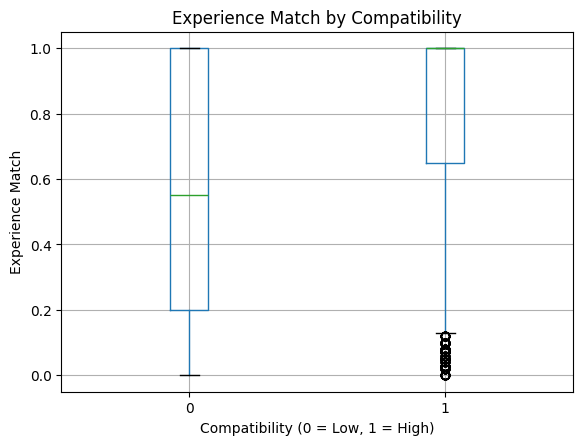

In [16]:
applications.boxplot(
    column="experience_match",
    by="compatibility"
)

plt.title("Experience Match by Compatibility")
plt.suptitle("")
plt.xlabel("Compatibility (0 = Low, 1 = High)")
plt.ylabel("Experience Match")
plt.show()

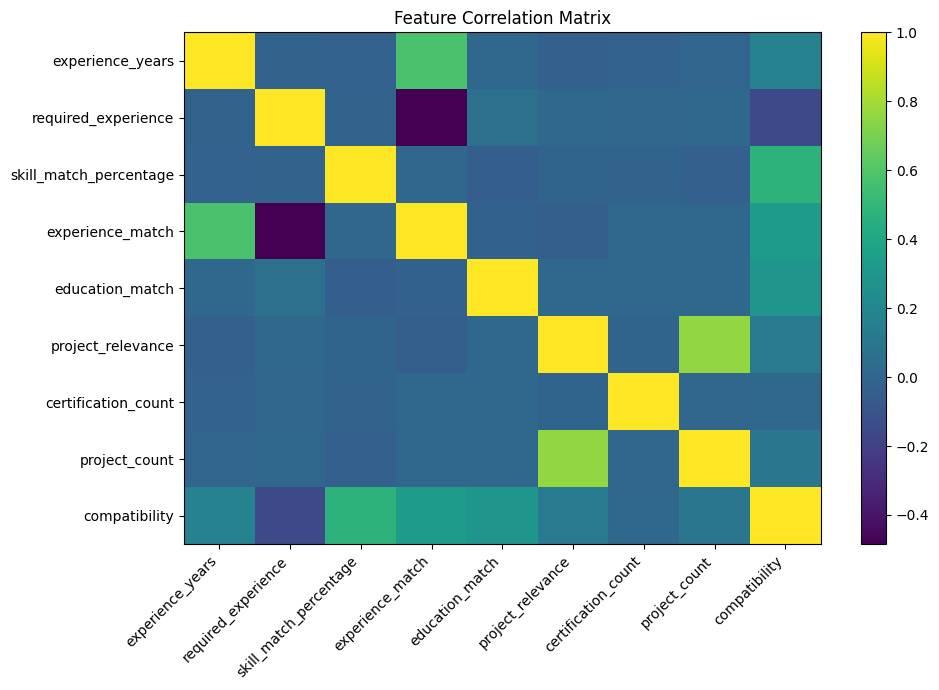

In [17]:
numeric_features = [
    "experience_years",
    "required_experience",
    "skill_match_percentage",
    "experience_match",
    "education_match",
    "project_relevance",
    "certification_count",
    "project_count",
    "compatibility"
]

correlation = applications[numeric_features].corr()

plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_features)),
    numeric_features
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [18]:
before = len(applications)

applications = applications.drop_duplicates().reset_index(drop=True)

after = len(applications)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 8000
Rows after removing duplicates: 7776
Duplicates removed: 224


In [19]:
feature_columns = [
    "education_level",
    "experience_years",
    "python",
    "sql",
    "machine_learning",
    "deep_learning",
    "power_bi",
    "excel",
    "cloud",
    "certification_count",
    "project_count",
    "internship_experience",
    "job_domain",
    "required_experience",
    "python_required",
    "sql_required",
    "ml_required",
    "dl_required",
    "power_bi_required",
    "excel_required",
    "cloud_required",
    "minimum_education",
    "skill_match_percentage",
    "experience_match",
    "education_match",
    "project_relevance"
]

X = applications[feature_columns]
y = applications["compatibility"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (7776, 26)
y shape: (7776,)

Target distribution:
compatibility
1    4461
0    3315
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 6220
Testing samples: 1556

Training target distribution:
compatibility
1    0.573633
0    0.426367
Name: proportion, dtype: float64

Testing target distribution:
compatibility
1    0.573907
0    0.426093
Name: proportion, dtype: float64


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "experience_years",
    "python",
    "sql",
    "machine_learning",
    "deep_learning",
    "power_bi",
    "excel",
    "cloud",
    "certification_count",
    "project_count",
    "internship_experience",
    "required_experience",
    "python_required",
    "sql_required",
    "ml_required",
    "dl_required",
    "power_bi_required",
    "excel_required",
    "cloud_required",
    "skill_match_percentage",
    "experience_match",
    "education_match",
    "project_relevance"
]

categorical_features = [
    "education_level",
    "job_domain",
    "minimum_education"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [23]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [24]:
y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred_logistic[:10])

Predictions generated successfully!
First 10 predictions:
[1 1 1 1 1 0 0 0 0 0]


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("-" * 35)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.8246
Precision: 0.8384
Recall   : 0.8600
F1-Score : 0.8491
ROC-AUC  : 0.9044


In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       663
           1       0.84      0.86      0.85       893

    accuracy                           0.82      1556
   macro avg       0.82      0.82      0.82      1556
weighted avg       0.82      0.82      0.82      1556



In [27]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))


Confusion Matrix:
[[515 148]
 [125 768]]


In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [29]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [30]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 30)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Results
------------------------------
Accuracy : 0.7918
Precision: 0.8103
Recall   : 0.8320
F1-Score : 0.8210
ROC-AUC  : 0.8735


In [32]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:
[[489 174]
 [150 743]]


In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("5-Fold Cross-Validation F1 Scores:")
print(cv_scores)

print("\nMean CV F1:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation F1 Scores:
[0.82778172 0.84313725 0.84852639 0.84188627 0.82744283]

Mean CV F1: 0.8377548908896287
Standard Deviation: 0.00857748406731012


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"]
}

grid_lr = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best parameters:")
print(grid_lr.best_params_)

print("\nBest cross-validation F1:")
print(grid_lr.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:
{'classifier__C': 1, 'classifier__solver': 'liblinear'}

Best cross-validation F1:
0.8378732036937775


In [35]:
best_lr_model = grid_lr.best_estimator_

y_pred_tuned = best_lr_model.predict(X_test)
y_prob_tuned = best_lr_model.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression")
print("-" * 35)

print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")

Tuned Logistic Regression
-----------------------------------
Accuracy : 0.8246
Precision: 0.8384
Recall   : 0.8600
F1-Score : 0.8491
ROC-AUC  : 0.9044


In [36]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))


Confusion Matrix:
[[515 148]
 [125 768]]


In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_score(y_test, y_pred_tuned)
    ],
    "F1-Score": [
        f1,
        f1_rf,
        f1_score(y_test, y_pred_tuned)
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf,
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8246,0.8384,0.860,0.8491,0.9044
1,Random Forest,0.7918,0.8103,0.832,0.8210,0.8735
2,Tuned Logistic Regression,0.8246,0.8384,0.860,0.8491,0.9044


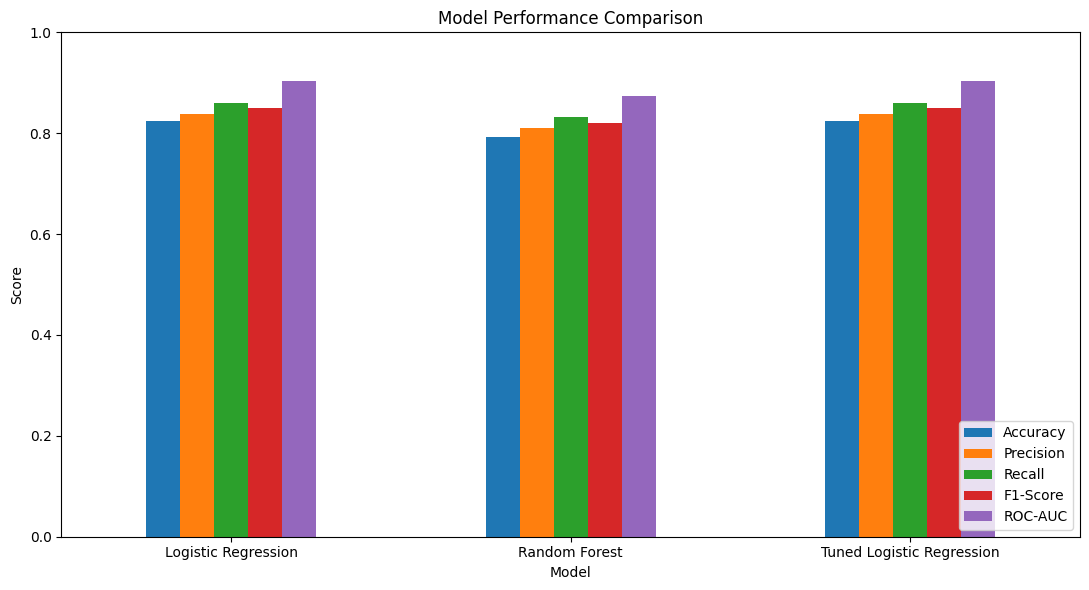

In [38]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [39]:
best_preprocessor = best_lr_model.named_steps["preprocessor"]

feature_names = best_preprocessor.get_feature_names_out()

coefficients = (
    best_lr_model
    .named_steps["classifier"]
    .coef_[0]
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["abs_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

feature_importance.head(15)

,feature,coefficient,abs_coefficient
19,num__skill_match_percentage,1.827766,1.827766
20,num__experience_match,1.315663,1.315663
21,num__education_match,1.194503,1.194503
22,num__project_relevance,0.649127,0.649127
23,cat__education_level_Bachelor's,0.135811,0.135811
33,cat__minimum_education_Master's,0.121095,0.121095
10,num__internship_experience,-0.111833,0.111833
32,cat__minimum_education_Diploma,0.094788,0.094788
30,cat__job_domain_Machine Learning,0.091568,0.091568
29,cat__job_domain_Data Science,0.087411,0.087411


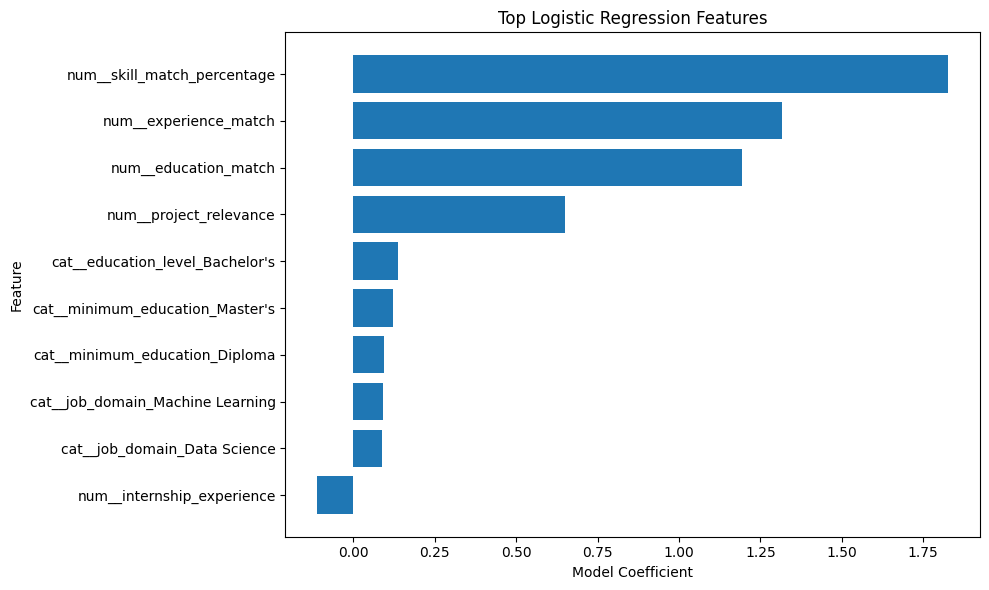

In [40]:
top_features = feature_importance.head(10).sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["coefficient"]
)

plt.xlabel("Model Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Features")
plt.tight_layout()
plt.show()

In [41]:
import joblib

joblib.dump(
    best_lr_model,
    "careermatch_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [45]:
def predict_compatibility(candidate, job):
    """
    Predict candidate-job compatibility.

    Parameters
    ----------
    candidate : dict
        Candidate information.

    job : dict
        Job information.

    Returns
    -------
    probability : float
        Probability of high compatibility.

    prediction : int
        0 = Low compatibility
        1 = High compatibility
    """

    # Calculate skill match
    skill_pairs = {
        "python": "python_required",
        "sql": "sql_required",
        "machine_learning": "ml_required",
        "deep_learning": "dl_required",
        "power_bi": "power_bi_required",
        "excel": "excel_required",
        "cloud": "cloud_required"
    }

    matched = 0
    required = 0

    for candidate_skill, job_skill in skill_pairs.items():

        if job[job_skill] == 1:
            required += 1

            if candidate[candidate_skill] == 1:
                matched += 1

    skill_match = (
        matched / required * 100
        if required > 0
        else 0
    )

    # Experience match
    if job["required_experience"] > 0:
        experience_match = min(
            candidate["experience_years"] /
            job["required_experience"],
            1
        )
    else:
        experience_match = 1

    # Education match
    education_mapping = {
        "Diploma": 1,
        "Bachelor's": 2,
        "Master's": 3
    }

    education_match = int(
        education_mapping[candidate["education_level"]]
        >=
        education_mapping[job["minimum_education"]]
    )

    # Project relevance
    project_score = min(
        candidate["project_count"] / 5,
        1
    )

    internship_score = candidate["internship_experience"]

    project_relevance = round(
        0.7 * project_score +
        0.3 * internship_score,
        2
    )

    # Create one-row DataFrame
    input_data = pd.DataFrame([{
        **candidate,
        **job,

        "skill_match_percentage": round(
            skill_match,
            2
        ),

        "experience_match": round(
            experience_match,
            2
        ),

        "education_match": education_match,

        "project_relevance": project_relevance
    }])

    # Select exactly the training features
    input_data = input_data[feature_columns]

    # Prediction
    probability = best_lr_model.predict_proba(
        input_data
    )[0, 1]

    prediction = int(
        probability >= 0.5
    )

    return probability, prediction

In [46]:
new_candidate = {
    "education_level": "Master's",
    "experience_years": 2.5,

    "python": 1,
    "sql": 1,
    "machine_learning": 1,
    "deep_learning": 0,
    "power_bi": 1,
    "excel": 1,
    "cloud": 0,

    "certification_count": 3,
    "project_count": 4,
    "internship_experience": 1
}

In [47]:
new_job = {
    "job_domain": "Data Science",
    "required_experience": 2,

    "python_required": 1,
    "sql_required": 1,
    "ml_required": 1,
    "dl_required": 0,
    "power_bi_required": 1,
    "excel_required": 0,
    "cloud_required": 0,

    "minimum_education": "Bachelor's"
}

In [48]:
probability, prediction = predict_compatibility(
    new_candidate,
    new_job
)

print(
    f"Compatibility probability: "
    f"{probability:.2%}"
)

print(
    "Prediction:",
    "High Compatibility"
    if prediction == 1
    else "Low Compatibility"
)

Compatibility probability: 99.80%
Prediction: High Compatibility


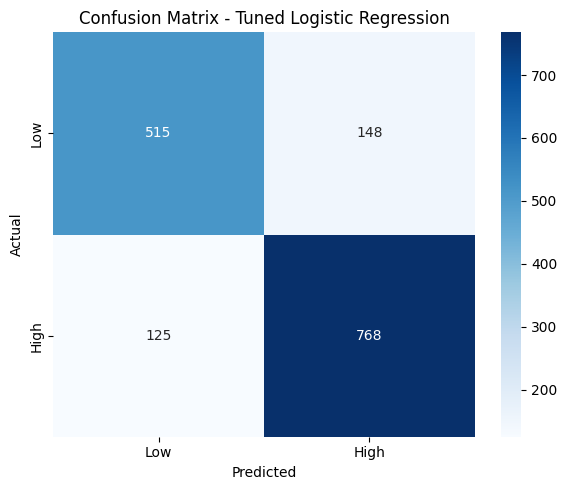

In [49]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

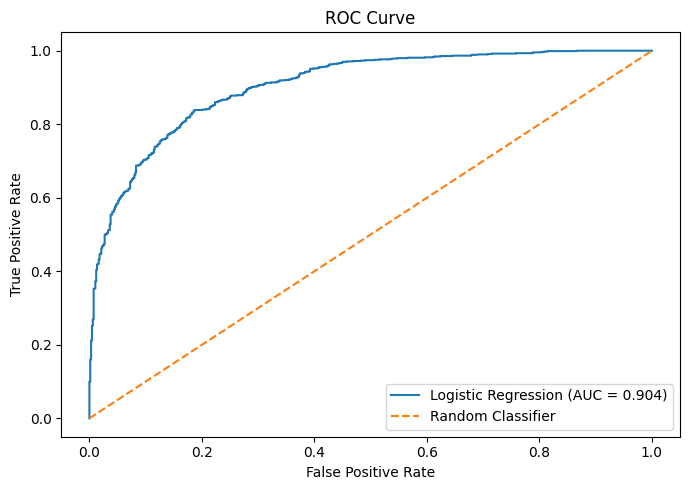

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_tuned
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_tuned):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
applications.to_csv(
    "candidate_job_compatibility.csv",
    index=False
)

print("Dataset saved successfully!")


Dataset saved successfully!


In [52]:
import os

print("Model exists:", os.path.exists("careermatch_model.pkl"))
print("Dataset exists:", os.path.exists("candidate_job_compatibility.csv"))

Model exists: True
Dataset exists: True


In [53]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_tuned >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1-Score": f1_score(
            y_test,
            predictions
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.3,0.7647,0.9462,0.8458
1,0.4,0.8020,0.9071,0.8513
2,0.5,0.8384,0.8600,0.8491
3,0.6,0.8683,0.7973,0.8313
4,0.7,0.8947,0.7234,0.8000


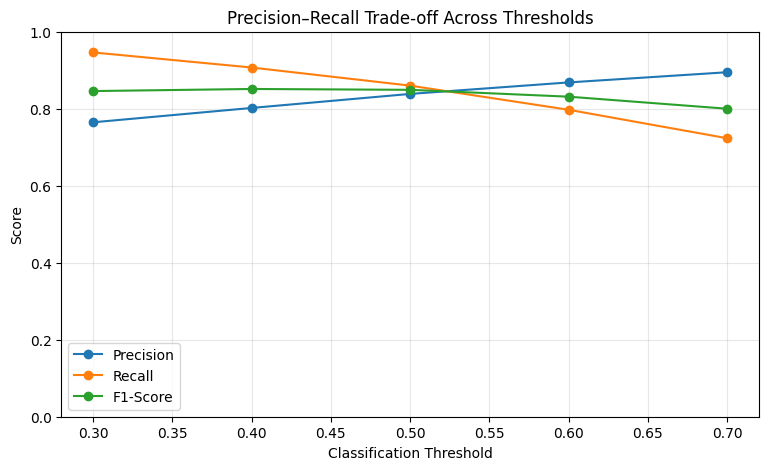

In [54]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off Across Thresholds")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
final_metrics = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        y_pred_tuned
    ),
    "Precision": precision_score(
        y_test,
        y_pred_tuned
    ),
    "Recall": recall_score(
        y_test,
        y_pred_tuned
    ),
    "F1-Score": f1_score(
        y_test,
        y_pred_tuned
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_tuned
    )
}

pd.DataFrame([final_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.8246,0.8384,0.86,0.8491,0.9044


In [56]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import joblib

requirements = f"""numpy=={np.__version__}
pandas=={pd.__version__}
matplotlib=={matplotlib.__version__}
seaborn=={sns.__version__}
scikit-learn=={sklearn.__version__}
joblib=={joblib.__version__}
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print(requirements)
print("requirements.txt created successfully!")

numpy==2.1.3
pandas==2.2.3
matplotlib==3.10.0
seaborn==0.13.2
scikit-learn==1.6.1
joblib==1.6.0

requirements.txt created successfully!


In [57]:
predict_script = r'''
import pandas as pd
import joblib


MODEL_PATH = "careermatch_model.pkl"

model = joblib.load(MODEL_PATH)


def predict_compatibility(candidate, job):
    """
    Predict candidate-job compatibility.

    Parameters
    ----------
    candidate : dict
        Candidate information.

    job : dict
        Job information.

    Returns
    -------
    probability : float
        Probability of high compatibility.

    prediction : int
        0 = Low Compatibility
        1 = High Compatibility
    """

    skill_pairs = {
        "python": "python_required",
        "sql": "sql_required",
        "machine_learning": "ml_required",
        "deep_learning": "dl_required",
        "power_bi": "power_bi_required",
        "excel": "excel_required",
        "cloud": "cloud_required"
    }

    matched = 0
    required = 0

    for candidate_skill, job_skill in skill_pairs.items():

        if job[job_skill] == 1:
            required += 1

            if candidate[candidate_skill] == 1:
                matched += 1

    skill_match = (
        matched / required * 100
        if required > 0
        else 0
    )

    experience_match = (
        min(
            candidate["experience_years"] /
            job["required_experience"],
            1
        )
        if job["required_experience"] > 0
        else 1
    )

    education_mapping = {
        "Diploma": 1,
        "Bachelor's": 2,
        "Master's": 3
    }

    education_match = int(
        education_mapping[candidate["education_level"]]
        >= education_mapping[job["minimum_education"]]
    )

    project_score = min(
        candidate["project_count"] / 5,
        1
    )

    internship_score = candidate["internship_experience"]

    project_relevance = (
        0.7 * project_score +
        0.3 * internship_score
    )

    input_data = pd.DataFrame([{
        **candidate,
        **job,
        "skill_match_percentage": round(
            skill_match, 2
        ),
        "experience_match": round(
            experience_match, 2
        ),
        "education_match": education_match,
        "project_relevance": round(
            project_relevance, 2
        )
    }])

    feature_columns = [
        "education_level",
        "experience_years",
        "python",
        "sql",
        "machine_learning",
        "deep_learning",
        "power_bi",
        "excel",
        "cloud",
        "certification_count",
        "project_count",
        "internship_experience",
        "job_domain",
        "required_experience",
        "python_required",
        "sql_required",
        "ml_required",
        "dl_required",
        "power_bi_required",
        "excel_required",
        "cloud_required",
        "minimum_education",
        "skill_match_percentage",
        "experience_match",
        "education_match",
        "project_relevance"
    ]

    input_data = input_data[feature_columns]

    probability = model.predict_proba(
        input_data
    )[0, 1]

    prediction = int(probability >= 0.5)

    return probability, prediction
'''

with open("predict.py", "w") as f:
    f.write(predict_script)

print("predict.py created successfully!")

predict.py created successfully!


In [58]:
import os

print("predict.py exists:", os.path.exists("predict.py"))

with open("predict.py", "r") as f:
    print(f.read()[:1000])

predict.py exists: True

import pandas as pd
import joblib


MODEL_PATH = "careermatch_model.pkl"

model = joblib.load(MODEL_PATH)


def predict_compatibility(candidate, job):
    """
    Predict candidate-job compatibility.

    Parameters
    ----------
    candidate : dict
        Candidate information.

    job : dict
        Job information.

    Returns
    -------
    probability : float
        Probability of high compatibility.

    prediction : int
        0 = Low Compatibility
        1 = High Compatibility
    """

    skill_pairs = {
        "python": "python_required",
        "sql": "sql_required",
        "machine_learning": "ml_required",
        "deep_learning": "dl_required",
        "power_bi": "power_bi_required",
        "excel": "excel_required",
        "cloud": "cloud_required"
    }

    matched = 0
    required = 0

    for candidate_skill, job_skill in skill_pairs.items():

        if job[job_skill] == 1:
            required += 1

            if candidate[c

In [59]:
gitignore_content = """__pycache__/
*.pyc
.ipynb_checkpoints/
.env
.DS_Store
"""

with open(".gitignore", "w") as f:
    f.write(gitignore_content)

print(".gitignore created successfully!")

.gitignore created successfully!


In [60]:
import os

print("Files created:")
for file in [
    "requirements.txt",
    "predict.py",
    ".gitignore",
    "careermatch_model.pkl",
    "candidate_job_compatibility.csv"
]:
    print(file, "→", os.path.exists(file))

Files created:
requirements.txt → True
predict.py → True
.gitignore → True
careermatch_model.pkl → True
candidate_job_compatibility.csv → True


In [69]:
%%writefile README.md
# CareerMatch ML

## Candidate–Job Compatibility Prediction Using Classical Machine Learning

CareerMatch ML is an end-to-end classical machine learning project that predicts candidate–job compatibility from structured candidate and job attributes.

## Problem Statement

This project formulates candidate–job compatibility as a binary classification problem:

- `0` = Low Compatibility
- `1` = High Compatibility

## Machine Learning Workflow

```text
Candidate + Job Data
        ↓
Data Cleaning
        ↓
Exploratory Data Analysis
        ↓
Feature Engineering
        ↓
Train/Test Split
        ↓
Preprocessing
        ↓
Logistic Regression
        ↓
Random Forest Comparison
        ↓
Cross-Validation
        ↓
Hyperparameter Tuning
        ↓
Model Evaluation
        ↓
Feature Interpretation
        ↓
Compatibility Prediction

Overwriting README.md


In [70]:
import os

print("README exists:", os.path.exists("README.md"))

with open("README.md", "r", encoding="utf-8") as f:
    content = f.read()

print("README size:", len(content), "characters")

README exists: True
README size: 834 characters


In [71]:
import os
import zipfile

files_to_package = [
    "CareerMatch_ML.ipynb",
    "candidate_job_compatibility.csv",
    "careermatch_model.pkl",
    "predict.py",
    "requirements.txt",
    ".gitignore",
    "README.md"
]

with zipfile.ZipFile("CareerMatch-ML.zip", "w") as zipf:
    for file in files_to_package:
        if os.path.exists(file):
            zipf.write(file)

print("CareerMatch-ML.zip created successfully!")
print("\nFiles included:")

with zipfile.ZipFile("CareerMatch-ML.zip", "r") as zipf:
    for file in zipf.namelist():
        print("✓", file)

CareerMatch-ML.zip created successfully!

Files included:
✓ candidate_job_compatibility.csv
✓ careermatch_model.pkl
✓ predict.py
✓ requirements.txt
✓ .gitignore
✓ README.md


In [72]:
import os

print("Notebook files:")
for file in os.listdir():
    if file.endswith(".ipynb"):
        print(file)

Notebook files:


In [73]:
from google.colab import files

files.download("CareerMatch-ML.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>